# BioDYM Material Flow Analysis - Scientific Notebook

A streamlined notebook for Material Flow Analysis using the BioDYM framework with enhanced plotting capabilities. 

## Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Validation** - Execute MFA analysis and verify results
3. **Visualization** - Comprehensive analysis and exploration
4. **Scenario & Uncertainty Manager** - (Optional) Compare scenarios and run Monte Carlo analysis
5. **Data Export** - Save results and generate documentation

---

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import copy

In [ ]:
# Add BioDYM modules to path
src_path = os.path.join(os.getcwd(), '02_src')
sys.path.insert(0, src_path)

In [ ]:
# Add ODYM framework to path
project_root = os.getcwd()
odym_path = os.path.join(
    project_root, "06_framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [ ]:
# Add bioDYM add-on to path
biodym_addon_path = os.path.join(
    project_root, "06_framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [ ]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    import plotting
    import ODYM_Classes as msc
    from plotting.composition import plot_flow_composition
    from reporting import kpi_dashboard
    
    # Import standard icons
    from constants import Icons, format_header, format_step, format_success, format_error, format_file_path
    
    print(f"{Icons.SUCCESS} BioDYM modules imported successfully")
except ImportError as e:
    print(f"{Icons.ERROR} Import error: {e}")
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [ ]:
# Set up plotting
plt.style.use('default')
print(f"{Icons.VISUALIZATION} Plotting environment ready")

📊 Plotting environment ready


## 1.2 Data Input Configuration

In [ ]:
# This is the only manual path setting required.
input_file = "01_data/01_input/251104_BioDYM_ODYM_´CE-RISE.xlsm"
print(format_file_path(input_file))
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

  📁 Loading: [01_data/01_input/251104_BioDYM_ODYM_´CE-RISE.xlsm]


## 1.3 System Configuration Extraction

In [ ]:
print(format_header("EXTRACTING CONFIGURATION FROM EXCEL"))


EXTRACTING CONFIGURATION FROM EXCEL



In [ ]:
# Load the full dataset once. This will be passed to functions that need it.
input_data = pd.read_excel(
    input_file, sheet_name=None, header=0, engine='openpyxl', na_values=['N.A.', 'NA', 'n/a'], decimal=',')
print(format_success(f"Excel file loaded: {len(input_data)} sheets"))

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validatio

✅ Excel file loaded: 21 sheets


c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



In [ ]:
# Use the robust loader from the config module. This function handles all errors
# and fallbacks, guaranteeing a valid config object is returned.
config_obj = config.load_configuration(input_file)
print(format_success("Configuration object loaded."))

[OK] Found configuration sheet: '0_Configuration'
[OK] Loaded 6 elements from configuration: ['material', 'CU', 'Fe', 'Al', 'plastics', 'hazardous_material']
   |-- E2 (CU) is expressed as % of material
   |-- E3 (Fe) is expressed as % of material
   |-- E4 (Al) is expressed as % of material
   |-- E5 (plastics) is expressed as % of material
   |-- E6 (hazardous_material) is expressed as % of material
[OK] Loaded 1 regions from configuration: ['Case_Study_Region']
[OK] Loaded 4 goods from configuration: ['Raw Material', 'Processed Product', 'Product', 'Waste']
[OK] Loaded 4 process types from configuration: ['Biomass Production', 'Biomass Processing', 'Use-Phase', 'EoL-Phase']
✅ Configuration object loaded.


c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



In [ ]:
# Phase 1b: Extract dimension lists from config
def get_config_list(config_obj, attribute_name, default=None):
    """Helper to extract comma-separated lists from config object."""
    if hasattr(config_obj, attribute_name):
        value = getattr(config_obj, attribute_name)
        if value and pd.notna(value):
            return [item.strip() for item in str(value).split(',') if item.strip()]
    return default

In [ ]:
regions = get_config_list(config_obj, 'Regions', ['Case_Study_Region'])
goods = get_config_list(config_obj, 'Goods', None)
materials = get_config_list(config_obj, 'Materials', None)
processes = get_config_list(config_obj, 'Process_Types', None)

In [ ]:
print(f"{Icons.VISUALIZATION} Dimensions loaded from configuration:")
print(f"   {Icons.ARROW} Regions: {regions}")
if materials:
    print(f"   - Materials: {materials}")
if goods:
    print(f"   - Goods: {goods}")
if processes:
    print(f"   - Process Types: {processes}")

📊 Dimensions loaded from configuration:
   → Regions: ['Case_Study_Region']
   - Goods: ['Raw Material', 'Processed Product', 'Product', 'Waste']
   - Process Types: ['Biomass Production', 'Biomass Processing', 'Use-Phase', 'EoL-Phase']


In [ ]:
# Extract core values from the config object, with fallbacks to data-driven values
try:
    start_year = int(config_obj.Start_Year)
    end_year = int(config_obj.End_Year)
    # Try different possible element attribute names
    if hasattr(config_obj, 'Elements'):
        elements = [elem.strip() for elem in config_obj.Elements.split(',')]
    elif hasattr(config_obj, 'Elements_comma_separated'):
        elements = [elem.strip() for elem in config_obj.Elements_comma_separated.split(',')]
    elif hasattr(config_obj, 'Element_list'):
        elements = [elem.strip() for elem in config_obj.Element_list.split(',')]
    else:
        raise AttributeError("No Elements attribute found in config object")
except Exception as e:
    print(f"{Icons.WARNING} Could not get time/elements from config object: {e}. Falling back to data-driven values.")
    flow_data = input_data['1_2_Data_Flows']
    # Fix: Use correct column name 'Flow_Data_Year' instead of 'Year_Flow'
    years = sorted(flow_data['Flow_Data_Year'].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ['material', 'WC', 'DM', 'CC']

In [ ]:
# Display final configuration summary
run_scenario = getattr(config_obj, 'Run_Scenario_Analysis', False)
selected_scenario = getattr(config_obj, 'Selected_Scenario_Name 1', getattr(config_obj, 'Selected_Scenario_Name', 'N/A'))

In [ ]:
print(f"\n-- Configuration Summary --")
print(f"{Icons.TIME} Time range: {start_year} - {end_year}")
print(f"{Icons.ELEMENT} Elements: {elements}")
print(f"{Icons.MONTE_CARLO} Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO else 'Disabled'}")
print(f"{Icons.DSM} DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION else 'Disabled'}")
print(f"{Icons.FOMP} FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION else 'Disabled'}")
print(f"{Icons.SCENARIO} Scenario Analysis: {'Enabled' if run_scenario else 'Disabled'}")
if run_scenario:
    print(f"   -> Selected Scenario: '{selected_scenario}'")


-- Configuration Summary --
📅 Time range: 2025 - 2050
🧪 Elements: ['material', 'CU', 'Fe', 'Al', 'plastics', 'hazardous_material']
🎲 Monte Carlo: Disabled
🏗️ DSM Calculation: Enabled
🌱 FOMP Calculation: Disabled
🎭 Scenario Analysis: Enabled
   -> Selected Scenario: 'N/A'


# 2. Calculation and Validation

In [ ]:
# ## 2.1 Model Initialization & Calculation
print(format_header("RUNNING BASELINE MFA CALCULATION"))


RUNNING BASELINE MFA CALCULATION



In [ ]:
print(format_step(Icons.SYSTEM, "2.1", "Setting up model scope..."))
model_classification, index_table = system_setup.define_model_scope(start_year, end_year, elements, regions, goods, materials, processes)

  🔧 [2.1] Setting up model scope...
--> Model scope and classifications defined with 2 dimensions.


In [ ]:
print(format_step(Icons.SYSTEM, "2.2", "Initializing MFA system..."))
mfa_system_base = system_setup.initialize_mfa_system(model_classification, index_table)

  🔧 [2.2] Initializing MFA system...
--> IndexTable validation passed.
--> MFA system object initialized.


In [ ]:
# Phase 1b: Display IndexTable (ODYM convention)
print(format_header("ODYM SYSTEM INDEX TABLE", level=2))
print(mfa_system_base.IndexTable)
print("\nAvailable Dimensions:")
for aspect in mfa_system_base.IndexTable.index:
    classification = mfa_system_base.IndexTable.loc[aspect, 'Classification']
    index_letter = mfa_system_base.IndexTable.loc[aspect, 'IndexLetter']
    print(f"  - {aspect} ({index_letter}): {len(classification.Items)} items")
    if len(classification.Items) <= 5:
        print(f"    Items: {classification.Items}")
    else:
        print(f"    Items (sample): {classification.Items[:3]} ... ({len(classification.Items)} total)")


ODYM SYSTEM INDEX TABLE

                    Description Dimension  \
Aspect                                      
Time        Model aspect "time"      Time   
Element  Model aspect "Element"   Element   

                                            Classification IndexLetter  
Aspect                                                                  
Time     <ODYM_Classes.Classification object at 0x00000...           t  
Element  <ODYM_Classes.Classification object at 0x00000...           e  

Available Dimensions:
  - Time (t): 26 items
    Items (sample): [np.int64(2025), np.int64(2026), np.int64(2027)] ... (26 total)
  - Element (e): 6 items
    Items (sample): ['material', 'CU', 'Fe'] ... (6 total)


In [ ]:
print(format_step(Icons.DATA_LOADING, "2.3", "Loading processes and data..."))
mfa_system_base, all_excel_data = system_setup.load_and_define_processes(mfa_system_base, input_data, data_loader)

  📥 [2.3] Loading processes and data...
--> Defining process and stock structures...
--> Validating input data structure...
  -> Using new E# format for element columns in '1_1_Definition_Flows'
  -> Using new E# format for element columns in '1_2_Data_Flows'
  -> Using unified configuration columns in '2_1_Definition_Processes'
  -> Using new E# format for element columns in '2_2_static_TCs'
  -> Using new E# format for element columns in '2_3_dynamic_TCs'
--> Input data validation successful.
--> Stock values initialized.


In [ ]:
print(format_step(Icons.DATA_LOADING, "2.4", "Defining flows and parameters..."))
mfa_system_configured, _, flow_tc_map, process_logic_map = system_setup.define_flows_and_parameters(mfa_system_base, all_excel_data)

  📥 [2.4] Defining flows and parameters...
--> Defining flows, parameters, and setting all initial values...
--> All flows initialized to zero.
[INFO] Using new E# format 'E1_value' for flow data
--> Populated data for primary input flows.
--> Loading initial stock parameters from sheet '2_4_Initial_Stock'...
--> Successfully loaded initial stock configurations for 0 process(es).
--> Parameter values initialized successfully.
--> Using hierarchical element calculation (Phase 5b)
    CU = material × fraction
    Fe = material × fraction
    Al = material × fraction
    plastics = material × fraction
    hazardous_material = material × fraction
--> Creating Flow-to-TC mapping...
  -> Detected new E# format for TC mapping
  -> Created TC mapping for 14 flows
--> Consistency check passed.


In [ ]:
print(format_step(Icons.CONFIGURATION, "2.5", "Loading model parameters (TCs, DSM, FOMP)..."))

  ⚙️ [2.5] Loading model parameters (TCs, DSM, FOMP)...


In [ ]:
# Centralized call to the new, unified TC loader
time_vector = mfa_system_configured.IndexTable.Classification['Time'].Items
elements_list = mfa_system_configured.Elements
tc_params = data_loader.load_tc_parameters(all_excel_data, elements_list, time_vector)
mfa_system_configured.ParameterDict.update(tc_params) # Add the new TC params to the system

--> Loading Transfer Coefficients using unified TC_Configuration...
--> INFO: Process 0 (Input) - skipping TCs (process type)
--> INFO: Process 2 (Output) - skipping TCs (process type)
--> WARNING: Process 3 (DSM) has TC_Configuration='No TC' - skipping TCs
--> INFO: Process 8 (Output) - skipping TCs (process type)
--> INFO: Process 9 (Input) - skipping TCs (process type)
  -> Detected new E# format for TC columns
  -> Processing static TCs for 2 processes...
    -> Loaded static TC: TC_E1_01_03 = 0.8
    -> Loaded static TC: TC_E1_01_02 = 0.2
    -> Loaded static TC: TC_E1_06_03 = 1.0
  -> Processing dynamic TCs for 4 processes...
    -> Loaded dynamic TC: TC_E1_04_03 (1 data points -> 26 time steps)
    -> Loaded dynamic TC: TC_E1_04_08 (1 data points -> 26 time steps)
    -> Loaded dynamic TC: TC_E1_05_06 (1 data points -> 26 time steps)
    -> Loaded dynamic TC: TC_E1_05_07 (1 data points -> 26 time steps)
    -> Loaded dynamic TC: TC_E1_05_08 (1 data points -> 26 time steps)
    -

In [ ]:
# Load other special model parameters
dsm_params = data_loader.load_dsm_parameters(all_excel_data)
if config_obj.RUN_FOMP_CALCULATION:
    fomp_params = data_loader.load_fomp_parameters(all_excel_data)
else:
    fomp_params = {}
uncertainty_params = data_loader.load_uncertainty_definitions(all_excel_data)

--> Loading DSM parameters from sheet '3_1_Definition_DSM'...
--> Using Process_Logic column from main sheet to identify DSM processes: [3]
--> Successfully loaded configurations for 1 DSM process(es).
--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
  DEBUG: df_uncertainty before dropna:
    ID  MC_Parameter  Parameter_Selection  Parameter_Name  Distribution_Type  \
0    1           NaN                  NaN             NaN                NaN   
1    2           NaN                  NaN             NaN                NaN   
2    3           NaN                  NaN             NaN                NaN   
3    4           NaN                  NaN             NaN                NaN   
4    5           NaN                  NaN             NaN                NaN   
5    6           NaN                  NaN             NaN                NaN   
6    7           NaN                  NaN             NaN                NaN   
7    8           NaN                  Na

In [ ]:
print(format_success("All parameters loaded and configured."))

✅ All parameters loaded and configured.


In [ ]:
print(format_step(Icons.CALCULATION, "2.6", "Running baseline calculation..."))
mfa_results_baseline, dsm_details_baseline = solver.run_mfa_calculation(mfa_system_configured, dsm_params, fomp_params, config_obj, flow_tc_map=flow_tc_map, process_logic_map=process_logic_map)
print(format_success("Baseline calculation completed successfully!"))

  🧮 [2.6] Running baseline calculation...
[DSM DEBUG] Iteration 0: Process 3, Inflows: ['F_01_03', 'F_04_03', 'F_06_03', 'F_07_03'], Total Inflow Sum: 18619751.08, Ready: True
=== DSM DEBUG for Process 3 ===

--- Processing Category 1 (Heatpump) ---
Inflow category 1: [397370.49195789 334901.59831579 412223.64429474 498339.80766316
 325469.94391579]... (first 5 years)

--- Initial Stock Processing ---

--- Final Results Summary ---
Total outflow from inflows: 7384317.53382224
Total outflow from initial stock: 0.0
Total outflow material: 7384317.53382224
Total stock accumulated from inflows: 46213303.68308634
=== END DSM DEBUG for Process 3 ===

✅ DSM validation passed for process 3
[DSM DEBUG] Iteration 1: Process 3, Inflows: ['F_01_03', 'F_04_03', 'F_06_03', 'F_07_03'], Total Inflow Sum: 27690186.72, Ready: True
=== DSM DEBUG for Process 3 ===

--- Processing Category 1 (Heatpump) ---
Inflow category 1: [398752.31310652 339746.89762867 426563.10447278 532592.42251166
 391966.61468016]

## 2.2 Mass Balance Validation

In [ ]:
print(format_header("MASS BALANCE VERIFICATION (BASELINE)", level=2))
plotting.plot_total_mass_balance_error(mfa_results_baseline)
plotting.plot_optimized_mass_balance_error(mfa_results_baseline)


MASS BALANCE VERIFICATION (BASELINE)



c:\Users\Johannes\Nextcloud\BioDYM\bioDYM-CERT-edit-main\02_src\plotting\export_publication.py:189: UserWarning:

Unknown size preset 'large'. Using current size.



✅ Exported PNG: 01_data\02_output\figures\mass_balance_total_20251106_123942.png (667.8 KB, 400 DPI)
✅ Exported PDF: 01_data\02_output\figures\mass_balance_total_20251106_123942.pdf (34.3 KB, 400 DPI)

✅ Figure exported: 01_data\02_output\figures\mass_balance_total_20251106_123942.png, 01_data\02_output\figures\mass_balance_total_20251106_123942.pdf


interactive(children=(IntSlider(value=2025, description='Year:', layout=Layout(width='400px'), max=2050, min=2…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Error: %{y:.2e} Mg<extra></extra>',
              'marker': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851],
                         'line': {'color': '#212529', 'width': 1}},
              'type': 'bar',
              'uid': '2a41fe84-f326-409c-b294-4c6a8927f011',
              'x': [Materials and Parts Production, Manufacturing ,
                    Production_waste, Use Phase, Repair, Decomissioning, Reuse,
                    Remanufacturing, Waste Treatment, Spare parts production ,
                    Spare parts storage],
              'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}],
    'layout': {'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 900,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
            


→ System Flow Diagram (Graphviz)
🔍 Graphviz Analysis:
   Input: 45 processes, 93 flows
   Data Quality Check:
   - Complete processes: 11/45
   - Complete flows: 16/93
   - Connected processes: 11
   Final: 11 processes, 16 flows
   ✅ Graphviz chart created successfully!


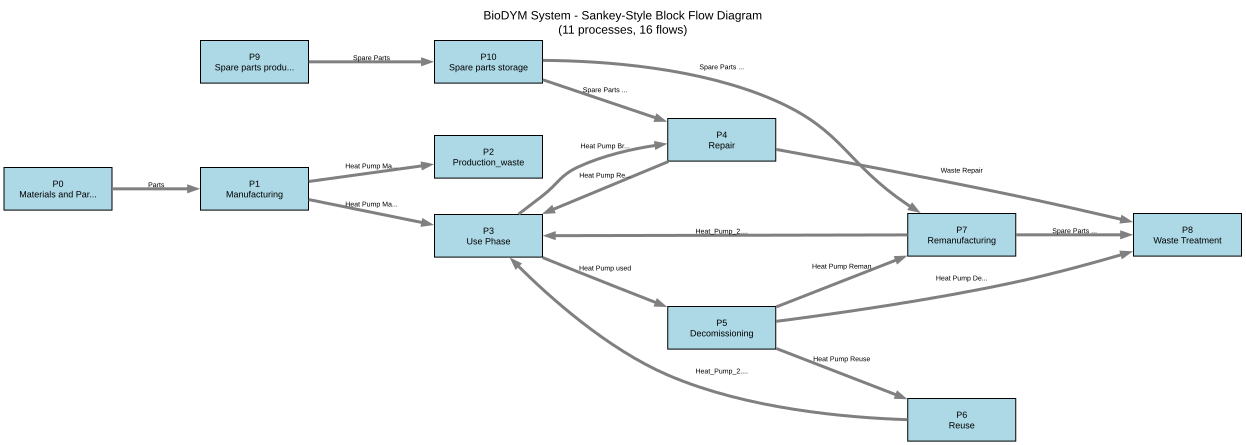

✅ Graphviz chart created successfully!


In [ ]:
# ## 2.3 System Flow Diagram (Graphviz)
print(f"\n{Icons.ARROW} System Flow Diagram (Graphviz)")
try:
    from plotting.graphviz_flow_charts import plot_graphviz_flow_chart_sankey_style
    
    # Get the required dataframes from the loaded data
    processes_data = all_excel_data['2_1_Definition_Processes']
    flows_data = all_excel_data['1_1_Definition_Flows']
    
    # Generate and display the chart
    dot_chart = plot_graphviz_flow_chart_sankey_style(processes_data, flows_data)
    if dot_chart:
        display(dot_chart)
        print(format_success("Graphviz chart created successfully!"))
except ImportError:
    print(f"{Icons.WARNING} Graphviz library not found. Skipping this plot.")
except Exception as e:
    print(f"{Icons.WARNING} Graphviz chart failed: {e}")

# 3. Visualization

In [ ]:
print(format_header("VISUALIZATION (BASELINE)"))


VISUALIZATION (BASELINE)



In [ ]:
# ## 3.1 Sankey Diagram
print(f"\n{Icons.ARROW} Sankey Diagram")
plotting.plot_interactive_sankey(mfa_results_baseline, dsm_params, fomp_params)


→ Sankey Diagram


FigureWidget({
    'data': [{'arrangement': 'snap',
              'link': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851],
                       'customdata': [F_00_01, F_01_03, F_01_02, F_03_04, F_04_03,
                                      F_09_10, F_10_04, F_04_08, F_03_05, F_05_06,
                                      F_05_07, F_10_07, F_07_08, F_05_08, F_06_03,
                                      F_07_03],
                       'hovertemplate': ('Flow: %{customdata}<br />Sourc' ... 'Value: %{value}<extra></extra>'),
                       'source': [0, 1, 1, 3, 4, 9, 10, 4, 3, 5, 5, 10, 7, 5, 6,
                                  7],
                       'target': [1, 3, 2, 4, 3, 10, 4, 8, 5, 6, 7, 7, 8, 8, 3, 3],
                       'value': [496713.1149473685, 397370

In [ ]:
# ## 3.2 Additional Visualizations
print(f"\n{Icons.ARROW} Additional Visualizations")


→ Additional Visualizations


In [ ]:
# ### 3.2.1 Core System Dynamics
print(f"\n{Icons.VISUALIZATION} Core System Dynamics:")
print("   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)")
print("   • Flow Dynamics: Multi-flow time series analysis")
print("   • Stock Analysis: Interactive bar charts with time slider")


📊 Core System Dynamics:
   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)
   • Flow Dynamics: Multi-flow time series analysis
   • Stock Analysis: Interactive bar charts with time slider


In [ ]:
# Process Dynamics - 3-panel view showing inflow, stock, and outflow for selected processes
print(f"\n{Icons.MFA} Process Dynamics Analysis:")
plotting.plot_process_dynamics(mfa_results_baseline, all_excel_data['2_1_Definition_Processes'])


🔄 Process Dynamics Analysis:


interactive(children=(Dropdown(description='Process:', layout=Layout(width='400px'), options=('Materials and P…

FigureWidget({
    'data': [{'line': {'color': '#00C851', 'width': 2},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': 'f93ad47c-e3eb-4b90-ad68-69a489f71bc5',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'line': {'color': '#6F42C1', 'width': 2},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Stock',
              'type': 'scatter',
              'uid': '00df9de9-eb7c-4bdc-bd7f-412fd57e0a7e',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 20

In [ ]:
# Flow Dynamics - Multi-flow time series with element selection
print(f"\n{Icons.SANKEY} Flow Dynamics Analysis:")
plotting.plot_flow_dynamics(mfa_results_baseline)


🌊 Flow Dynamics Analysis:


interactive(children=(SelectMultiple(description='Flows:', index=(0,), layout=Layout(width='400px'), options=(…

FigureWidget({
    'data': [{'line': {'width': 2},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'F_00_01',
              'type': 'scatter',
              'uid': '9f56486b-52f5-4028-a71a-b42b2635fb95',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': {'bdata': ('UsO0dSRRHkEvHtj9C40ZQdZ/sjg+cx' ... 'k3yg9BSpUxLKqAFkHintKy02sbQQ=='),
                    'dtype': 'f8'}}],
    'layout': {'barmode': 'overlay',
               'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth': 1,
                          'font': {'color': '#212529', 'family': 'Arial, san

In [ ]:
# Stock Bar Chart - Interactive stock levels with time slider
print(f"\n{Icons.BAR_CHART} Stock Levels Analysis:")
plotting.plot_stock_bar_chart(mfa_results_baseline, title="Stock Levels Over Time (Baseline)")


📈 Stock Levels Analysis:


interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': [#2ca02c, #2ca02c, #2ca02c, #2ca02c, #2ca02c,
                                   #2ca02c, #2ca02c, #2ca02c]},
              'type': 'bar',
              'uid': 'a8c4e299-191a-44ef-a5cd-260bd463f085',
              'x': array(['Materials and Parts Production', 'Production_waste', 'Use Phase',
                          'Reuse', 'Remanufacturing', 'Waste Treatment',
                          'Spare parts production ', 'Spare parts storage'], dtype=object),
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f8'}}],
    'layout': {'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth

In [ ]:
# System Stock Composition - Individual process stocks over time
print(f"\n{Icons.BAR_CHART} Individual Process Stocks Analysis:")
print("   • Individual process stocks over time")
print("   • Shows each process stock separately")
print("   • Element selection and bar/line chart options")
plotting.plot_system_stock_composition(mfa_results_baseline)


📈 Individual Process Stocks Analysis:
   • Individual process stocks over time
   • Shows each process stock separately
   • Element selection and bar/line chart options


FigureWidget({
    'data': [], 'layout': {'template': '...'}
})

In [ ]:
# ### 3.2.2 Specialized Process Analysis (if applicable)
print(f"\n{Icons.VISUALIZATION} Specialized Process Analysis:")


📊 Specialized Process Analysis:


In [ ]:
# DSM Stock Details - Detailed DSM stock evolution (if DSM processes exist)
if dsm_params and dsm_details_baseline:
    print(f"\n{Icons.DSM} DSM Stock Evolution Analysis:")
    print("   • Individual and cumulative stock views")
    print("   • Lifetime analysis and category breakdown")
    plotting.plot_dsm_stock_details(mfa_results_baseline, dsm_params, dsm_details_baseline)
    
    print(f"\n{Icons.MFA} DSM Process Dynamics Analysis:")
    print("   • Three-panel view: Input, Stock, Output")
    print("   • Stacked flows by element (Material, WC, DM, CC)")
    print("   • Dynamic material composition for DSM processes")
    plotting.plot_dsm_process_dynamics(mfa_results_baseline, dsm_params, dsm_details_baseline)
else:
    print(f"   {Icons.INFO} No DSM processes found - skipping DSM analysis")

In [ ]:
# FOMP Analysis - FOMP mineralization analysis (if FOMP processes exist)
if fomp_params:
    print(f"\n{Icons.FOMP} FOMP Mineralization Analysis:")
    print("   • Organic matter accumulation and mineralization")
    print("   • Annual vs cumulative flow analysis")
    plotting.plot_fomp_stock_details(mfa_results_baseline, fomp_params)
    
    # FOMP Process Dynamics - Three-panel view of FOMP processes
    print(f"\n{Icons.MFA} FOMP Process Dynamics:")
    print("   • Three panels: Input Flows (DM), Stock Evolution (DM), Mineralization Output (DM)")
    print("   • Decay rates displayed as percentages")
    print("   • Water Content (WC) excluded from mineralization")
    plotting.plot_fomp_dynamics(mfa_results_baseline, fomp_params)
else:
    print(f"   {Icons.INFO} No FOMP processes found - skipping FOMP analysis")

In [ ]:
# ### 3.2.3 Flow Composition
print(f"\n{Icons.SUBSECTION} Flow Composition")
plot_flow_composition(mfa_results_baseline)

In [ ]:
# Export flow composition data
from plotting.composition_export import export_flow_composition
export_path = "01_data/02_output/composition_export/flow_composition.xlsx"
export_flow_composition(mfa_results_baseline, export_path)

# 4. Scenario & Uncertainty Manager

In [ ]:
# ## 4.1 Scenario Analysis & Comparison
print(format_header("SCENARIO ANALYSIS"))

In [ ]:
# Import the new scenario engine
from engine import scenario_engine

In [ ]:
# Run scenario analysis using the new engine
all_scenario_results, scenario_definitions = scenario_engine.run_scenario_analysis(
    config_obj=config_obj,
    mfa_system_configured=mfa_system_configured,
    all_excel_data=all_excel_data,
    dsm_params=dsm_params,
    fomp_params=fomp_params,
    flow_tc_map=flow_tc_map,
    process_logic_map=process_logic_map
)

In [ ]:
# Generate visualizations if scenarios were run
if all_scenario_results:
    scenario_engine.generate_scenario_comparison_visualizations(
        baseline_results=mfa_results_baseline,
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
    
    # Export scenario results
    scenario_engine.export_scenario_results(
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
else:
    print(f"{Icons.INFO} No scenarios were processed.")

In [ ]:
# ## 4.2 Monte Carlo Analysis
print(format_header("MONTE CARLO SIMULATION (BASELINE)", level=2))

In [ ]:
if config_obj.RUN_MONTE_CARLO and '4_1_Uncertainty_Parameters' in input_data:
    try:
        from engine.mc_simulation import run_mc_simulation
        from engine.mc_simulation import run_mc_simulation
        from plotting.monte_carlo import (
            plot_interactive_mc_multiple_histograms,
            plot_interactive_tornado, 
            plot_interactive_mc_paths, 
            plot_interactive_mc_stock_comparison
        )
        from plotting.composition import plot_flow_composition        
        mc_results = run_mc_simulation(
            mfa_system_configured, 
            input_data, 
            dsm_params, 
            fomp_params, 
            config_obj, 
            process_logic_map=process_logic_map, 
            flow_tc_map=flow_tc_map
        )
        
        if mc_results is not None and not mc_results.empty:
            print(format_success("Monte Carlo simulation completed for baseline."))

            # --- Export MC Results ---
            print(f"\n{Icons.EXPORT} Exporting Monte Carlo results...")
            from datetime import datetime
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            mc_output_path = f"01_data/02_output/mc_output/mc_results_detailed_{timestamp}.xlsx"
            try:
                mc_results.to_excel(mc_output_path, index=False)
                print(format_success(f"Monte Carlo results successfully exported to: {mc_output_path}"))
            except Exception as export_error:
                print(f"{Icons.WARNING} Could not export Monte Carlo results: {export_error}")
            # -------------------------

            print(f"\n{Icons.VISUALIZATION} Monte Carlo Analysis Visualizations:")
            print("   • Multiple Distribution Histograms: Interactively select and view histograms for multiple stocks.")
            print("   • Sensitivity Tornado Plot: Identify which parameters most influence outcomes.")
            print("   • Simulation Paths: Visualize the trajectories of all Monte Carlo runs.")
            print("   • Stock Comparison: Compare distributions of several stocks in one plot.")

            # This new function allows selecting multiple histograms, making the old single one redundant.
            plot_interactive_mc_multiple_histograms(mc_results, mfa_results_baseline)
            
            plot_interactive_tornado(mc_results)
            plot_interactive_mc_paths(mc_results, mfa_results_baseline)
            plot_interactive_mc_stock_comparison(mc_results, mfa_results_baseline)
            
    except Exception as e:
        print(f"{Icons.WARNING} Monte Carlo simulation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"{Icons.INFO} Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.")

# 5. Data Export

In [ ]:
print(format_header("EXPORTING BASELINE RESULTS"))

## 5.1 KPI Dashboard and Export

In [ ]:
kpi_output_path = "01_data/02_output/kpi_dashboard/system_kpis.xlsx"
print(format_step(Icons.EXPORT, "5.1", "Generating KPI Dashboard..."))
kpi_dashboard.generate_kpi_dashboard(mfa_results_baseline, process_logic_map, kpi_output_path)

In [ ]:
print(format_step(Icons.EXPORT, "5.2", "Exporting baseline results..."))
output_file = "01_data/02_output/results_scientific_baseline.xlsx"
utils.export_results_to_excel(mfa_results_baseline, output_file, input_file_path=input_file)
print(format_success(f"Baseline results exported to: {output_file}"))

In [ ]:
print(format_header("ANALYSIS COMPLETE"))